In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
okc_data = pd.read_csv('../data/raw/okc_2526.csv', index_col = 'GAME_DATE', parse_dates = True).drop(columns=['Unnamed: 0'], errors='ignore')
sas_data = pd.read_csv('../data/raw/sas_2526.csv', index_col = 'GAME_DATE', parse_dates = True).drop(columns=['Unnamed: 0'], errors='ignore')

print(okc_data.head())

                MATCHUP WL  PTS  PLUS_MINUS  FGA  FG_PCT  FTA  OREB   TOV  \
GAME_DATE                                                                   
2025-10-21  OKC vs. HOU  W  125         1.0  104   0.442   25    11  12.0   
2025-10-23    OKC @ IND  W  141         6.0   95   0.453   51     9  14.0   
2025-10-25    OKC @ ATL  W  117        17.0   93   0.462   19    15  13.0   
2025-10-27    OKC @ DAL  W  101         7.0   90   0.467   13     9  13.0   
2025-10-28  OKC vs. SAC  W  107         6.0   92   0.457   10    10  15.0   

            POINTS_AGAINST    PACE  IS_HOME  PLAYOFF  
GAME_DATE                                             
2025-10-21           124.0  116.00        1    False  
2025-10-23           135.0  122.44        0    False  
2025-10-25           100.0   99.36        0    False  
2025-10-27            94.0   99.72        0    False  
2025-10-28           101.0  101.40        1    False  


## Scoring Averages by Season/Playoff & Home/Away

In [4]:
def get_team_metrics(team_df):
    team_avg_pts_scored = team_df['PTS'].mean()
    team_avg_pts_against = team_df['POINTS_AGAINST'].mean()
    team_season_home_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 1) & (team_df['PLAYOFF']==0), 'PTS'].mean()
    team_season_away_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 0) & (team_df['PLAYOFF']==0), 'PTS'].mean()
    team_playoff_home_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 1) & (team_df['PLAYOFF']==1), 'PTS'].mean()
    team_playoff_away_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 0) & (team_df['PLAYOFF']==1), 'PTS'].mean()
    
    return team_avg_pts_scored, team_avg_pts_against, team_season_home_avg_pts_scored, team_season_away_avg_pts_scored, team_playoff_home_avg_pts_scored, team_playoff_away_avg_pts_scored

In [5]:
okc_avg_pts_scored, okc_avg_pts_against, okc_season_home_avg_pts_scored, okc_season_away_avg_pts_scored, okc_playoff_home_avg_pts_scored, okc_playoff_away_avg_pts_scored = get_team_metrics(okc_data)
sas_avg_pts_scored, sas_avg_pts_against, sas_season_home_avg_pts_scored, sas_season_away_avg_pts_scored, sas_playoff_home_avg_pts_scored, sas_playoff_away_avg_pts_scored = get_team_metrics(sas_data)

print(okc_avg_pts_scored)

119.20652173913044


In [6]:
summary = pd.DataFrame({
    'Metric': ['Avg PTS Scored', 'Avg PTS Against',
               'Home PTS (RS)', 'Away PTS (RS)',
               'Home PTS (PO)', 'Away PTS (PO)'],
    'OKC': [okc_avg_pts_scored, okc_avg_pts_against,
            okc_season_home_avg_pts_scored, okc_season_away_avg_pts_scored,
            okc_playoff_home_avg_pts_scored, okc_playoff_away_avg_pts_scored],
    'SAS': [sas_avg_pts_scored, sas_avg_pts_against,
            sas_season_home_avg_pts_scored, sas_season_away_avg_pts_scored,
            sas_playoff_home_avg_pts_scored, sas_playoff_away_avg_pts_scored],
})
print(summary.to_string(index=False))

         Metric        OKC        SAS
 Avg PTS Scored 119.206522 119.442105
Avg PTS Against 107.804348 110.621053
  Home PTS (RS) 119.146341 120.525000
  Away PTS (RS) 118.902439 119.166667
  Home PTS (PO) 118.166667 114.833333
  Away PTS (PO) 124.500000 118.857143


## Scoring Points Distribution by Team


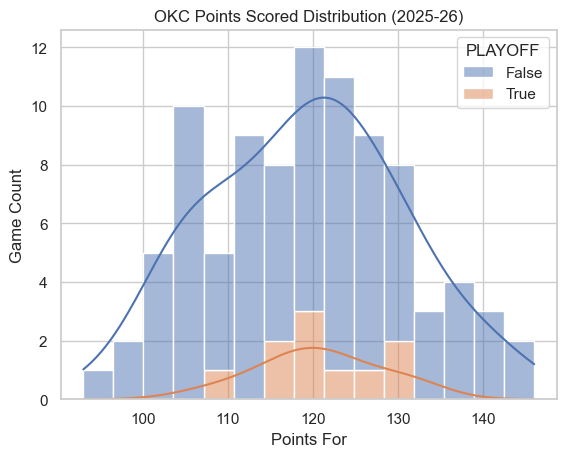

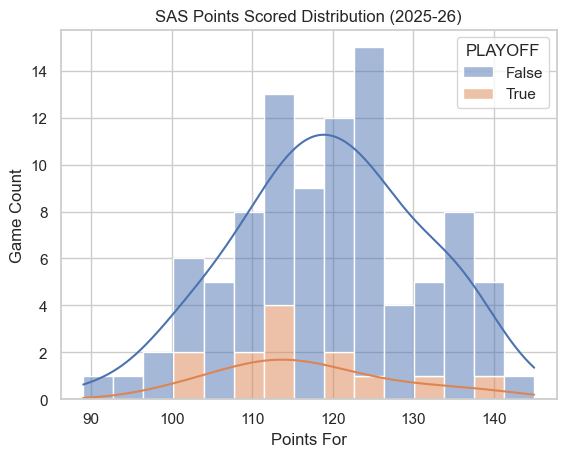

In [7]:
sns.set_theme(style="whitegrid")

# OKC Point distribution
sns.histplot(data=okc_data, x='PTS', hue = 'PLAYOFF', multiple = "stack", bins=15, kde=True)

plt.title('OKC Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

# SAS Point distribution
sns.histplot(data=sas_data, x='PTS', hue = 'PLAYOFF', multiple = "stack", bins=15, kde=True)

plt.title('SAS Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

## Team Recent Scoring form

In [8]:
def plot_recent_form(team_df, team_name):
    plt.figure(figsize=(12, 5))

    # Plot Points Scored
    sns.lineplot(
        x=team_df.index, 
        y=team_df['PTS'], 
        marker='o', 
        linewidth=2, 
        label='Points Scored (Offense)', 
        color='blue'
    )

    # Plot Points Conceded
    sns.lineplot(
        x=team_df.index, 
        y=team_df['POINTS_AGAINST'], 
        marker='o', 
        linewidth=2, 
        label='Points Against (Defense)', 
        color='red'
    )

    plt.title(f'{team_name} Recent Form: Offense vs. Defense (Last 15 Games)')
    plt.xlabel('Game Date')
    plt.ylabel('Points')
    plt.legend()

    plt.show()

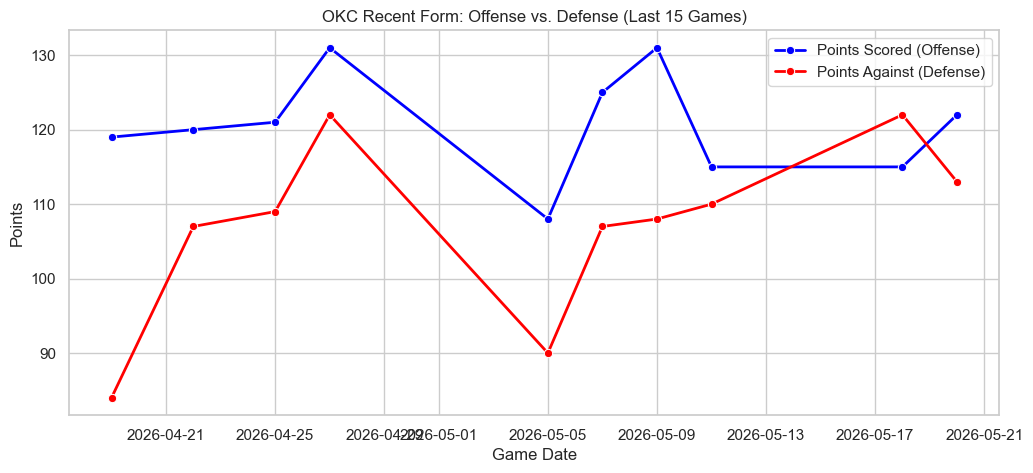

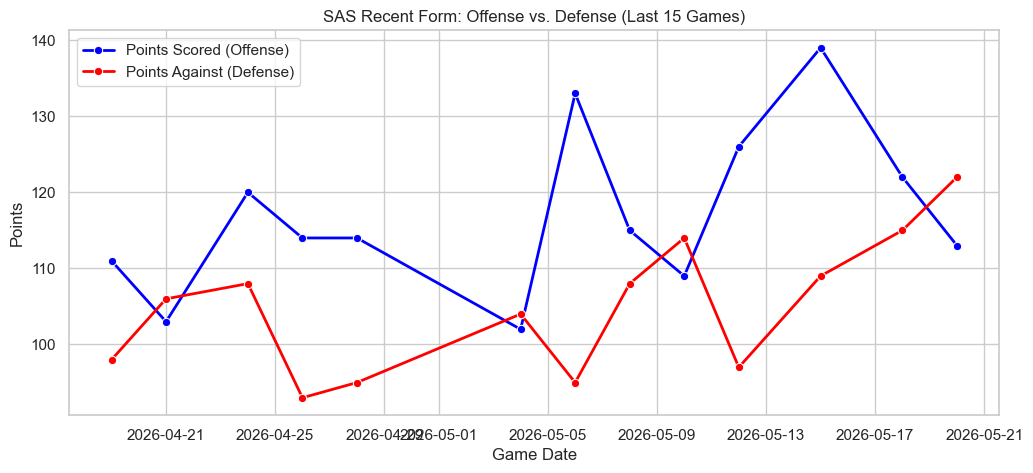

In [9]:
#Check Recent form of both teams: Last 15 games
okc_recent_form = okc_data[okc_data['PLAYOFF'] == 1]
sas_recent_form = sas_data[sas_data['PLAYOFF'] == 1]

plot_recent_form(okc_recent_form, "OKC")
plot_recent_form(sas_recent_form, "SAS")

## Head to Head data between OKC and SAS

In [10]:
# Head to Head data
h2h = okc_data[okc_data['MATCHUP'].str.contains('SAS')]

print("--- OKC vs SAS Head-to-Head ---")
print(h2h[['MATCHUP', 'WL', 'PTS', 'POINTS_AGAINST', 'PLUS_MINUS']])
print(f"OKC record vs SAS: {(h2h['WL']=='W').sum()}W - {(h2h['WL']=='L').sum()}L")
print(f"OKC avg pts in H2H: {h2h['PTS'].mean():.1f}")
print(f"SAS avg pts in H2H: {h2h['POINTS_AGAINST'].mean():.1f}")

--- OKC vs SAS Head-to-Head ---
                MATCHUP WL  PTS  POINTS_AGAINST  PLUS_MINUS
GAME_DATE                                                  
2025-12-13    OKC @ SAS  L  109           111.0        -2.0
2025-12-23    OKC @ SAS  L  110           130.0       -20.0
2025-12-25  OKC vs. SAS  L  102           117.0       -15.0
2026-01-13  OKC vs. SAS  W  119            98.0        21.0
2026-02-04    OKC @ SAS  L  106           116.0       -10.0
2026-05-18  OKC vs. SAS  L  115           122.0        -7.0
2026-05-20  OKC vs. SAS  W  122           113.0         9.0
OKC record vs SAS: 2W - 5L
OKC avg pts in H2H: 111.9
SAS avg pts in H2H: 115.3


## PACE by Season and Playoff

In [11]:
print(f"OKC Season avg PACE: {okc_data.loc[okc_data['PLAYOFF']== False, 'PACE'].mean():.1f}")
print(f"SAS Season avg PACE: {sas_data.loc[sas_data['PLAYOFF']== False, 'PACE'].mean():.1f}")

print(f"OKC Playoff avg PACE: {okc_data.loc[okc_data['PLAYOFF']== True, 'PACE'].mean():.1f}")
print(f"SAS Playoff avg PACE: {sas_data.loc[sas_data['PLAYOFF']== True, 'PACE'].mean():.1f}")
# And split by playoff vs regular season

OKC Season avg PACE: 102.3
SAS Season avg PACE: 102.8
OKC Playoff avg PACE: 99.3
SAS Playoff avg PACE: 101.6


---
## Eastern Conference Finals: New York Knicks vs Cleveland Cavaliers

In [12]:
nyk_data = pd.read_csv('../data/raw/nyk_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')
cle_data = pd.read_csv('../data/raw/cle_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')

print(nyk_data.tail())
print(cle_data.tail())

                MATCHUP WL  PTS  PLUS_MINUS  FGA  FG_PCT  FTA  OREB   TOV  \
GAME_DATE                                                                   
2026-05-04  NYK vs. PHI  W  137        39.0   84   0.631   17     8  15.0   
2026-05-06  NYK vs. PHI  W  108         6.0   79   0.506   25     9  13.0   
2026-05-08    NYK @ PHI  W  108        14.0   76   0.500   32    13  15.0   
2026-05-10    NYK @ PHI  W  144        30.0   91   0.538   29    15  11.0   
2026-05-19  NYK vs. CLE  W  115        11.0   88   0.477   32     9  19.0   

            POINTS_AGAINST    PACE  IS_HOME  PLAYOFF  
GAME_DATE                                             
2026-05-04            98.0   98.48        1     True  
2026-05-06           102.0   94.00        1     True  
2026-05-08            94.0   92.08        0     True  
2026-05-10           114.0   99.76        0     True  
2026-05-19           104.0  112.08        1     True  
                MATCHUP WL  PTS  PLUS_MINUS  FGA  FG_PCT  FTA  OREB   TOV  

### Scoring Averages by Season/Playoff & Home/Away

In [13]:
nyk_avg, nyk_against, nyk_rs_home, nyk_rs_away, nyk_po_home, nyk_po_away = get_team_metrics(nyk_data)
cle_avg, cle_against, cle_rs_home, cle_rs_away, cle_po_home, cle_po_away = get_team_metrics(cle_data)

ecf_summary = pd.DataFrame({
    'Metric': ['Avg PTS Scored', 'Avg PTS Against',
               'Home PTS (RS)', 'Away PTS (RS)',
               'Home PTS (PO)', 'Away PTS (PO)'],
    'NYK': [nyk_avg, nyk_against, nyk_rs_home, nyk_rs_away, nyk_po_home, nyk_po_away],
    'CLE': [cle_avg, cle_against, cle_rs_home, cle_rs_away, cle_po_home, cle_po_away],
})
print(ecf_summary.to_string(index=False))

         Metric        NYK        CLE
 Avg PTS Scored 116.860215 118.041237
Avg PTS Against 109.075269 114.453608
  Home PTS (RS) 119.000000 119.170732
  Away PTS (RS) 114.023810 119.878049
  Home PTS (PO) 117.500000 114.571429
  Away PTS (PO) 122.800000 105.875000


### Scoring Points Distribution by Team

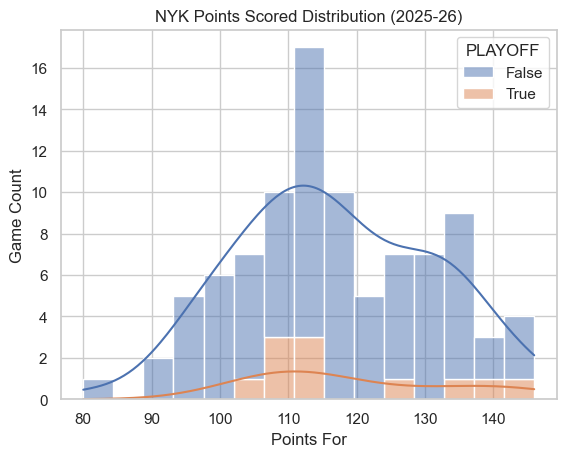

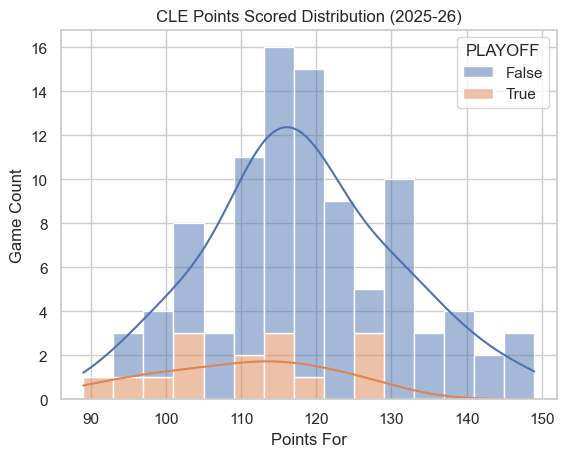

In [14]:
sns.set_theme(style="whitegrid")

sns.histplot(data=nyk_data, x='PTS', hue='PLAYOFF', multiple="stack", bins=15, kde=True)
plt.title('NYK Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

sns.histplot(data=cle_data, x='PTS', hue='PLAYOFF', multiple="stack", bins=15, kde=True)
plt.title('CLE Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

### Recent Playoff Form

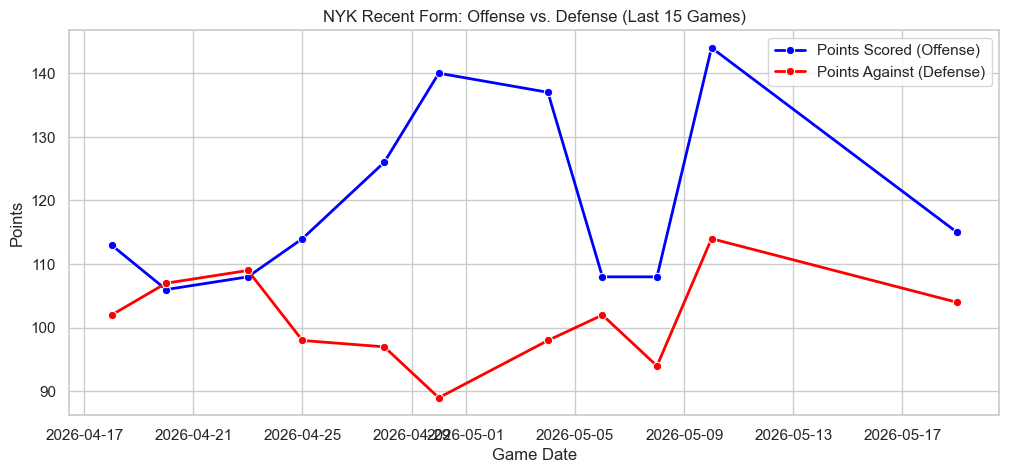

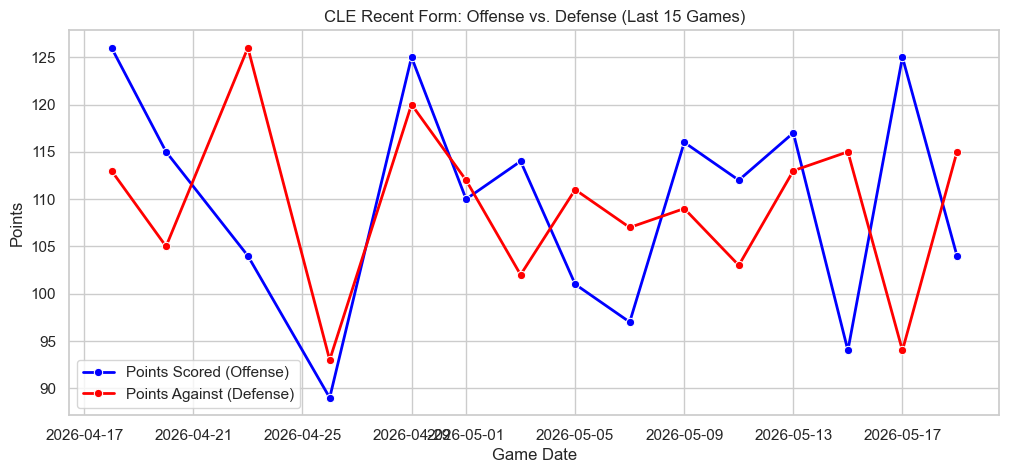

In [15]:
nyk_playoff_form = nyk_data[nyk_data['PLAYOFF'] == True]
cle_playoff_form = cle_data[cle_data['PLAYOFF'] == True]

plot_recent_form(nyk_playoff_form, "NYK")
plot_recent_form(cle_playoff_form, "CLE")

### Head-to-Head: NYK vs CLE

In [16]:
h2h_nyk = nyk_data[nyk_data['MATCHUP'].str.contains('CLE')]

print("--- NYK vs CLE Head-to-Head ---")
print(h2h_nyk[['MATCHUP', 'WL', 'PTS', 'POINTS_AGAINST', 'PLUS_MINUS']])
print(f"NYK record vs CLE: {(h2h_nyk['WL']=='W').sum()}W - {(h2h_nyk['WL']=='L').sum()}L")
print(f"NYK avg pts in H2H: {h2h_nyk['PTS'].mean():.1f}")
print(f"CLE avg pts in H2H: {h2h_nyk['POINTS_AGAINST'].mean():.1f}")

--- NYK vs CLE Head-to-Head ---
                MATCHUP WL  PTS  POINTS_AGAINST  PLUS_MINUS
GAME_DATE                                                  
2025-10-22  NYK vs. CLE  W  119           111.0         8.0
2025-12-25  NYK vs. CLE  W  126           124.0         2.0
2026-02-24    NYK @ CLE  L   94           109.0       -15.0
2026-05-19  NYK vs. CLE  W  115           104.0        11.0
NYK record vs CLE: 3W - 1L
NYK avg pts in H2H: 113.5
CLE avg pts in H2H: 112.0


### PACE by Season and Playoff

In [17]:
print(f"NYK Season avg PACE: {nyk_data.loc[nyk_data['PLAYOFF'] == False, 'PACE'].mean():.1f}")
print(f"CLE Season avg PACE: {cle_data.loc[cle_data['PLAYOFF'] == False, 'PACE'].mean():.1f}")
print(f"NYK Playoff avg PACE: {nyk_data.loc[nyk_data['PLAYOFF'] == True, 'PACE'].mean():.1f}")
print(f"CLE Playoff avg PACE: {cle_data.loc[cle_data['PLAYOFF'] == True, 'PACE'].mean():.1f}")

NYK Season avg PACE: 99.7
CLE Season avg PACE: 102.8
NYK Playoff avg PACE: 99.4
CLE Playoff avg PACE: 99.8
